In [1]:
from inu.io import basic_formats
from inu.ds.models import *
from inu.ds.resource import ModelManager, DEFAULT_DIRS, ManagedModel
import deepdiff
from inu.ds.scheme import PathScheme, MetaForms, MetaSrc
from inu.ds.models import SchemeModel
from inu.ds.collect import DataCollection
from inu.pipelines.benchmark.core import Benchmark
from inu.pipelines.benchmark.models import *
import tempfile
import pytest
import iplantuml

Model can not generate fully defined default configuration!
Creating template for model <class 'inu.ds.models.DatasetModel'>
Model can not generate fully defined default configuration!
Creating template for model <class 'inu.ds.models.SchemeModel'>
Model can not generate fully defined default configuration!
Creating template for model <class 'inu.ds.models.CollectionModel'>


/home/itayo/code/algodev/inu/param/models.py:249: UserWarning: Callable reader_Callable[[Union[pathlib.Path, str], str, ...], dict] was excluded from schema since JSON schema has no equivalent type.
  f.write(cls.schema_json(indent=2))
/home/itayo/code/algodev/inu/param/models.py:249: UserWarning: Callable meta_Callable was excluded from schema since JSON schema has no equivalent type.
  f.write(cls.schema_json(indent=2))


Tensor Flow not installed - can't use TF engines
onnx not installed - can't use onnx engines
Model can not generate fully defined default configuration!
Creating template for model <class 'inu.pipelines.benchmark.models.BenchmarkModel'>


/home/itayo/code/algodev/inu/param/models.py:249: UserWarning: Callable reader_Callable[[Union[pathlib.Path, str], str, ...], dict] was excluded from schema since JSON schema has no equivalent type.
  f.write(cls.schema_json(indent=2))
/home/itayo/code/algodev/inu/param/models.py:249: UserWarning: Callable meta_Callable was excluded from schema since JSON schema has no equivalent type.
  f.write(cls.schema_json(indent=2))


# Problem Statetment

1. Running different kind of processes: Benchmarks, Training, Data Access which of them are based on configurations.

1. Those configurations are in from of yml files.

1. We need to manage those configurations, and provide possibilties to:
    
    - Reproduce
    - Share
    - Find
    - Ensure Validity
    - Manage versions


# Proposal

- We introduce repositories for configurations based on folders.

- Configurations could be of different kinds, by the process being configured (Benchmark, Training, etc).

- Formal structure of such kind is represented by pydantic model, which takes care of validation.

- We introduce generic configuration manager to acces them (Add, Find..)

## Example of finding configuration of specific kind

Writing output for /home/itayo/code/algodev/inu/ds/tests/a1bf2903-19f5-4fa1-b883-fbd8afcc120e.uml to a1bf2903-19f5-4fa1-b883-fbd8afcc120e.svg


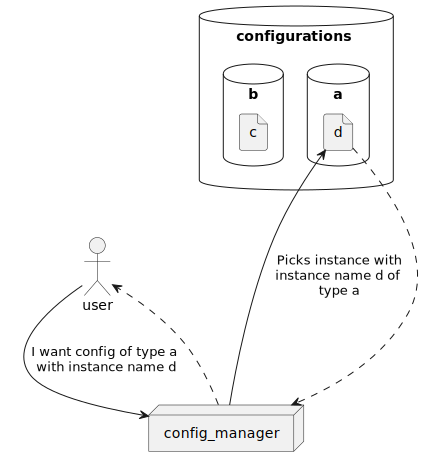

In [2]:
%%plantuml
@startuml
actor user
node config_manager

database configurations {
    database a {
        file d
    }
    
    database b {
        file c
    }
}

user -> config_manager : "I want config of type a \nwith instance name d"
    
config_manager -> d : "Picks instance with \ninstance name d of \ntype a"
d ...> config_manager
config_manager ..> user
@enduml

# Concrete Examples

## ModelManager API

In [3]:
ModelManager.list()

[<DatasetModel|0>, <SchemeModel|0>, <CollectionModel|0>, <BenchmarkModel|0>]

In [4]:
schemes = ModelManager.find_config_manager('scheme')
schemes

<SchemeModel|0>

In [5]:
schemes.rescan_folders()
schemes

<SchemeModel|20>

In [6]:
schemes.folders

['/home/itayo/code/algodev/resources/schemes']

In [7]:
schemes.list_configs()

,name,description,dataset
0,ETH3D,NaN,ETH3D
1,CRES,NaN,CRES
2,SF_FT3D,SceneFlow FlyingThings 3D,SF_FT3D
3,FT3D_nu40,NaN,SF_FT3D
4,KITTI15,NaN,KITTI
5,FT3D,NaN,FT3D
6,MONKNU40,Synthetic scenes with disparity and optical fl...,MONK
7,SF_FT3D_EVAL,SceneFlow FlyingThings3D evaluation scheme,FT3D
8,DRIV,NaN,DRIV
9,SF_MONK,Synthetic scenes with disparity and optical flow,SF_MONK


In [8]:
schemes.find_config('ETH3D')

<SchemeModel>
  name: ETH3D
  dataset: ETH3D
  pattern: {scene}/(?:(?P<kind>[^\d\/]+)(?P<view>\d)|(?=calib))(?P<alg>
           [^_\d\\/]*)\.(?P<ext>pfm|png|txt)
  mappings: {'view': {'0': 'L', '1': 'R'}, 'kind': {'im': 'image', 'mask': 'rgns'}, 'alg': {'nocc': 'ds'}}
  labels: {"if alg == ''": {'alg': 'cam', 'range': '0,255'}, "if alg == 'calib'": {'kind': 'meta'}, "transforms if alg == 'gt'": {'recode': {'from_to': [inf, nan]}}, "transforms if kind == 'rgns' and alg == 'ds'": {'regions': {'invl': 0, 'occl': 128, 'nocc': 255}}}
  search: {'max_depth': 3}
  if alg == '': {'alg': 'cam', 'range': '0,255'}
  transforms if kind == 'rgns' and alg == 'ds': {'regions': {'invl': 0, 'occl': 128, 'nocc': 255}}
  if alg == 'calib': {'kind': 'meta'}
  transforms if alg == 'gt': {'recode': {'from_to': [inf, nan]}}

In [9]:
schemes.find_config('ETH3D', out='model')

<SchemeModel>
  name: ETH3D
  dataset: ETH3D
  pattern: {scene}/(?:(?P<kind>[^\d\/]+)(?P<view>\d)|(?=calib))(?P<alg>
           [^_\d\\/]*)\.(?P<ext>pfm|png|txt)
  mappings: {'view': {'0': 'L', '1': 'R'}, 'kind': {'im': 'image', 'mask': 'rgns'}, 'alg': {'nocc': 'ds'}}
  labels: {"if alg == ''": {'alg': 'cam', 'range': '0,255'}, "if alg == 'calib'": {'kind': 'meta'}, "transforms if alg == 'gt'": {'recode': {'from_to': [inf, nan]}}, "transforms if kind == 'rgns' and alg == 'ds'": {'regions': {'invl': 0, 'occl': 128, 'nocc': 255}}}
  search: {'max_depth': 3}
  if alg == '': {'alg': 'cam', 'range': '0,255'}
  transforms if kind == 'rgns' and alg == 'ds': {'regions': {'invl': 0, 'occl': 128, 'nocc': 255}}
  if alg == 'calib': {'kind': 'meta'}
  transforms if alg == 'gt': {'recode': {'from_to': [inf, nan]}}

In [10]:
schemes.folders

['/home/itayo/code/algodev/resources/schemes']

In [11]:
! tree {schemes.folders[0]}

/home/itayo/code/algodev/resources/schemes
└── depth
    ├── CRES.scm.yml
    ├── depth_rec_inu.yml
    ├── depth_rec_scandy.yml
    ├── DRIV_DPE.scm.yml
    ├── DRIV.scm.yml
    ├── ETH3D.scm.yml
    ├── FLT.scm.yml
    ├── FT3D_DPE.scm.yml
    ├── FT3D_EVAL.scm.yml
    ├── FT3D.scm.yml
    ├── KITTI15.scm.yml
    ├── LOWLIGHT.scm.yml
    ├── MID.scm.yml
    ├── MONK_DPE.scm.yml
    ├── MONK.scm.yml
    ├── SF_DRIV.scm.yml
    ├── SF_FT3D_EVAL.scm.yml
    ├── SF_FT3D_NU40.scm.yml
    ├── SF_FT3D.scm.yml
    ├── SF_MONK.scm.yml
    ├── SINT.scm.yml
    ├── stereo_pair.yml
    ├── TARTAN.scm.yml
    └── tiny.scm.yml

1 directory, 24 files


### Defining PathScheme using SchemeModel

In [12]:
PathScheme.from_config('FT3D')

<PathScheme>: FT3D
	categories: [dataset, view, scene, subset, kind, range, ext, alg]
	bundle: []

In [13]:
PathScheme(**schemes.find_config('FT3D', out='dict'))

<PathScheme>: FT3D
	categories: [dataset, view, scene, subset, kind, range, ext, alg]
	bundle: []

### Using model validation capability to create configuration

In [14]:
scm = schemes.model(pattern='file.ext')
PathScheme(**scm.dict()).config.pattern

'file.ext'

## Defining new configuration model

In [15]:
class TestModel(YamlModel, desc='', patterns=['.dply.yml']):
    
    platform: str
    
    @validator('platform')
    def validate_platform(cls, v):
        assert v != 'linux'
        return v

In [16]:
TestModel(**dict(platform='windows'))

<TestModel> platform: windows

## Manage new class

### resource

In [17]:
print(resource.__doc__)


    Creates decorator for a YamlModel to manage it as a resource.
    Does not alter the model in any way.
    Resource files will be searched by matching the scheme regular expression.

    :param folders: root where such files should be looked for
    :param scheme: scheme or pattern of files with models configurations
    :param kwargs: additional PathScheme arguments (if scheme is a pattern)!
    :param scan_now: whether to load the default configration associated with the resource
    


Writing output for /home/itayo/code/algodev/inu/ds/tests/859da57e-874b-469d-b0dc-c9afc22effad.uml to 859da57e-874b-469d-b0dc-c9afc22effad.svg


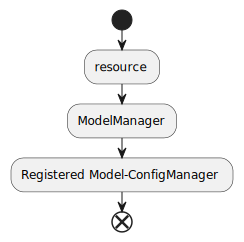

In [18]:
%%plantuml
@startuml
start
:resource;
:ModelManager;
:Registered Model-ConfigManager;
end
@enduml

In [19]:
@resource()
class TestModel(YamlModel, desc='', patterns=['.dply.yml']):
    
    platform: str
    
    @validator('platform')
    def validate_platform(cls, v):
        assert v != 'linux'
        return v

In [20]:
ModelManager.list()

[<DatasetModel|9>,
 <SchemeModel|20>,
 <CollectionModel|0>,
 <BenchmarkModel|0>,
 <TestModel|0>]

In [21]:
test_dir = Path('~/code/algodev/inu/ds/tests/data').expanduser().__str__()

In [22]:
!tree {test_dir}

/home/itayo/code/algodev/inu/ds/tests/data
├── level_one_1
│   ├── file_sceneA_id0.txt
│   └── file_sceneA_id1.txt
├── level_one_2
│   ├── file_sceneA_id0.txt
│   └── file_sceneA_id1.txt
├── level_two_1
│   ├── file_sceneB_id0.txt
│   └── file_sceneB_id1.txt
├── level_two_2
│   ├── file_sceneB_id0.txt
│   └── file_sceneB_id1.txt
├── scheme.yml
├── tiny_stereo
│   ├── Adirondack
│   │   ├── calib.txt
│   │   ├── disp0GT.tif
│   │   ├── disp1GT.tif
│   │   ├── im0_gray.jpg
│   │   ├── im0.jpg
│   │   ├── im0_reference.jpg
│   │   ├── im1_gray.jpg
│   │   ├── im1.jpg
│   │   ├── mask0nocc.jpg
│   │   └── mask1nocc.jpg
│   ├── dataset.yml
│   └── Piano
│       ├── calib.txt
│       ├── disp0GT.tif
│       ├── disp1GT.tif
│       ├── im0_gray.jpg
│       ├── im0.jpg
│       ├── im1_gray.jpg
│       ├── im1.jpg
│       ├── mask0nocc.jpg
│       └── mask1nocc.jpg
└── wind.dply.yml

7 directories, 30 files


In [23]:
test = ModelManager.find_config_manager(TestModel)
test.set_folders(test_dir)
test.rescan_folders()
ModelManager.list()

[<DatasetModel|9>,
 <SchemeModel|20>,
 <CollectionModel|0>,
 <BenchmarkModel|0>,
 <TestModel|1>]

In [24]:
from inu.ds.models import *
from inu.ds.resource import *
from inu.ds.scheme import PathScheme
import iplantuml
from inu.pipelines.benchmark.models import BenchmarkModel
import pytest

### ManagedModel

In [25]:
from inu.ds.tests.test_res import DeploymentModel

In [26]:
print(ManagedModel.__doc__)


    Class that holds the functionality to parse fields of type pydantic BaseModel that are managed.
    Those fields, are supersets of BaseModels named YamlModel.
    YamlModel hold the functionality to parse YML configurations.
    This class is designed to be base class for YamlModels which potentially have fields that needs to be managed.
    


In [27]:
@resource()
class SystemModel(ManagedModel, desc='', patterns=['.dply.yml']):
    
    deployment: Union[str, DeploymentModel]

In [28]:
SystemModel.parse_obj({'deployment': 'wind'})

<SystemModel> deployment: wind

In [29]:
SystemModel.parse_obj({'deployment': 'wind'}).deployment

'wind'

## Configurable

### Managed

- The class that gives a configrable the abillity to be configured.

- Configured objects are ensured to be properly defined by their underlying configuration class. 

- That means, that the model's fields must be a subset of the class constructor arguemnts.

Any Managed class allows access to:
1. The configrable Model - the specific class of its configuration
1. The configuration itself

Below is the example from previous workshop - DoplymentModel. 

We will create a new class "Deployer" that being configured using "DeploymentModel"

In [30]:
class Deployer(Managed, model=DeploymentModel):
    def __init__(self, name:str, description:str, platform: str):
        super().__init__(name=name, description=description, platform=platform)
        self.name = name
        self.description = description
        self.platform = platform

### Instantiation Using Model Instance - Creating a specific Configurable using specfic Configuration

In [31]:
d = Deployer.from_config('wind')

In [32]:
isinstance(ModelManager.find_config_manager(DeploymentModel).find_config('wind'), DeploymentModel)

True

In [33]:
isinstance(d, Deployer)

True

In [34]:
Deployer.model

inu.ds.tests.test_res.DeploymentModel

In [35]:
d.config

name: 'wind'
description: 'deployment on windows'
platform: 'windows'

In [36]:
ModelManager.find(DeploymentModel, name='wind', out='file', fail=False)

'/home/itayo/code/algodev/inu/ds/tests/data/wind.dply.yml'

## Changes in configuration formats

We introduce single directory to hold all the configurations.

This directory is in the algodev repository, nested under 'resources'.

In [37]:
!tree /home/$USER/code/algodev/resources -d

/home/itayo/code/algodev/resources
├── benchmarks
├── collections
├── datasets
├── lossfunctions
├── schemes
│   └── depth
├── templates
└── trainings

8 directories


# Common Configurations

PathScheme configuration split into two:

1. Structure, filters and transformations.

1. Dataset properties

The configurations corresponding models are:

1. SchemeModel

1. DatasetModel

Those configurations nested under datasets and scemes diretories.

## Scheme

```yml
name: tiny
dataset: tiny
pattern: '{scene}/((?P<kind>[^\d\\/]+)(?P<view>\d)|(?=calib))(?P<alg>[^_\s\\/]*)_?(?P<chn>[a-z]*)\.(?P<ext>tif|jpg|txt)'

mappings:
    view: { "0": L, "1": R }
    kind: { im: image, mask: rgns }
    alg: { nocc: ds }  # occlusion and invalid regions information

bundle: [ scene ]

# assign `alg` and `chn` for imaging data
if alg == '' and chn == '':
    chn: RGB
    alg: cam

if alg == '' and chn == 'gray':
    alg: c2g             # grey images were produced by rgb2grey

if chn == '': # preferable to have NaN than empty string
    chn: null

if alg == 'calib':
    kind: meta

if alg == 'cam':
    range: "0,255"

transforms if alg == 'GT':
    recode: {from_to: [.inf, .nan]}     # recode .inf -> .nan

transforms if kind == 'rgns' and alg == 'ds':   # transform into Regions type
    regions: { invl: 0, occl: 128, nocc: 255 }

search:
  ignore_case: True
  under_found: True
  max_depth: 3
```

## Dataset

```yml
name: tiny
description: Tiny version of the Middlebury 2014 stereo dataset for tests
alias: tiny
domain: depth
realism: true
```

DataCollections are represented with CollectionModel and nested under collections.

An example of collection configuration:

## Collection


```yml
name: test
description: Collection of ...

schemes:
    - tiny
    - name: MID
      dataset: MID14S
      filters:
        scene:
          - Vintage
```

Benchmark configurations are represented be BenchmarkModel and nested under benchmarks.

An example of benchmark configuration:

## Benchmark


```yml
name: 'test'
description: 'benchmark for testing'
adapter: disparity   # adapter module full or relative name (in inu.eval package)
                     # must include

inputs: tiny

evaluation:
    algorithms:
        SENSE:
```

The BenchmarkModel is taking care of all the defaults, which can be overriden when necessary.